<a href="https://colab.research.google.com/github/sitizaniahuny/step-1-BPPN-skripsi-/blob/main/step_1_Ver_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

In [2]:
FILE_NAME = "/content/passengers.xlsx"

MAX_MISSING_PCT = 30
REMOVE_HIGH_MISSING = False

^ masi dibuat *false* so that we can inspect the missing-data situation dulu

In [3]:
if FILE_NAME.lower().endswith(".csv"):
    df = pd.read_csv(FILE_NAME)

elif FILE_NAME.lower().endswith(".xlsx"):
    df = pd.read_excel(FILE_NAME)

else:
    raise ValueError("Please use a CSV or XLSX file.")
print("ORIGINAL DATA")
print(df.head())

print("\nData size:",df.shape)
print("\nColumn names:")
print(df.columns.tolist())

ORIGINAL DATA
        Station      Month  Passengers
0  Adi Soemarmo 2018-01-01         NaN
1  Adi Soemarmo 2018-02-01         NaN
2  Adi Soemarmo 2018-03-01         NaN
3  Adi Soemarmo 2018-04-01         NaN
4  Adi Soemarmo 2018-05-01         NaN

Data size: (2813, 3)

Column names:
['Station', 'Month', 'Passengers']


In [4]:
df = df.rename(columns={"Nama_Stasiun": "Station","Bulan": "Month","Jumlah_Penumpang": "Passengers"})
required_columns = ["Station","Month","Passengers"]
for col in required_columns:

    if col not in df.columns:

        raise ValueError(f"Column '{col}' was not found.")

# **CLEANING**

convert month to date

In [5]:
df["Month"] = pd.to_datetime(df["Month"],errors="coerce")

make all dates the first day of each month

In [6]:
df["Month"] = (df["Month"].dt.to_period("M").dt.to_timestamp())

convert passenger numbers to numeric

In [7]:
df["Passengers"] = pd.to_numeric(df["Passengers"],errors="coerce")

remove rows kalo station atau Month nya missing

In [8]:
df = df.dropna(subset=["Station","Month"]).copy()

clean station names

In [9]:
df["Station"] = (df["Station"].astype(str).str.strip())

#duplicate check

If more than one record exists for the same
station and month, passenger values are summed.

This is appropriate if several records represent
components of the monthly total.

In [10]:
duplicate_count = df.duplicated(
    subset=["Station","Month"]).sum()
print("DUPLICATE CHECK")
print("Number of duplicate Station-Month records:",duplicate_count)

DUPLICATE CHECK
Number of duplicate Station-Month records: 0


In [11]:
df = (df.groupby(["Station","Month"],as_index=False)
    .agg(Passengers=("Passengers",lambda x: x.sum(min_count=1))))

data sorting

In [12]:
df = df.sort_values(
    ["Station","Month"]
).reset_index(
    drop=True)

monthly series


In [13]:
complete_data = []
for station in df["Station"].unique():
    temp = df[
        df["Station"] == station
    ].copy()
    temp = temp.sort_values("Month")

    full_months = pd.date_range(
        start=temp["Month"].min(),
        end=temp["Month"].max(),
        freq="MS"
    )

    temp = (temp.set_index("Month").reindex(full_months))

    temp.index.name = "Month"


    #Restore station name
    temp["Station"] = station
    complete_data.append(temp)

df_complete = pd.concat(
    complete_data
).reset_index()

df_complete = df_complete.sort_values(
    ["Station","Month"]
).reset_index(
    drop=True)

missing value identification

In [14]:
df_complete["Was_Missing"] = (
    df_complete["Passengers"]
    .isna()
    .astype(int))

print("MISSING DATA")
print("Total missing observations:",df_complete["Was_Missing"].sum())


MISSING DATA
Total missing observations: 1401


missing value per stasiun

In [15]:
missing_summary = (
    df_complete
    .groupby("Station")
    .agg(Total_Months=("Month","size"),Missing_Months=("Was_Missing","sum"))
    .reset_index())

missing_summary["Missing_Percentage"] = (missing_summary["Missing_Months"]
    /
    missing_summary["Total_Months"]
    * 100)

missing_summary = (missing_summary.sort_values("Missing_Percentage",ascending=False)
    .reset_index(drop=True))
print("\nMissing data by station:")
print(missing_summary)


Missing data by station:
                             Station  Total_Months  Missing_Months  \
0                          Kebonromo            97              97   
1                      Kedungbanteng            97              96   
2                            Masaran            97              96   
3                           Klaten X            97              90   
4   Bandara Internasional Yogyakarta            97              90   
5                      Lempuyangan X            97              90   
6                       Yogyakarta X            97              90   
7                        Purwosari X            97              90   
8                              Palur            97              90   
9                     Solo Balapan X            97              88   
10                         Brambanan            97              60   
11                            Maguwo            97              59   
12                             Jenar            97              

identify high missing stations

In [16]:
high_missing_stations = (
    missing_summary[
        missing_summary[
            "Missing_Percentage"
        ] > MAX_MISSING_PCT
    ]["Station"]
    .tolist())
print(f"\nStations with more than "f"{MAX_MISSING_PCT}% missing:")
print(high_missing_stations)
if REMOVE_HIGH_MISSING:
    df_complete = df_complete[
        ~df_complete[
            "Station"].isin(high_missing_stations)
    ].copy()
    print("\nStations with high missing data "
    "have been removed.")



Stations with more than 30% missing:
['Kebonromo', 'Kedungbanteng', 'Masaran', 'Klaten X', 'Bandara Internasional Yogyakarta', 'Lempuyangan X', 'Yogyakarta X', 'Purwosari X', 'Palur', 'Solo Balapan X', 'Brambanan', 'Maguwo', 'Jenar', 'Pasarnguter', 'Sukoharjo', 'Solokota', 'Wonogiri', 'Kadipiro', 'Adi Soemarmo']


complete monthly series
march 2019 otomatis jadi missing obs

# IMPUTE MISSING VALUE
biar ga pake future leakage;
1st choice nya t-12 (pake data bulan yg sama tp di tahun sebelumnya)
2nd choice nya pake t-1

In [17]:
def historical_imputation(group):
    group = group.sort_values("Month").copy()
    values = (
        group["Passengers"]
        .astype(float)
        .to_numpy())


    for i in range(
        len(values)):
        if np.isnan(
            values[i]):

            # First choice: t-12
            # same month previous year
            if (
                i >= 12
                and
                not np.isnan(
                    values[i - 12]
                )
            ):

                values[i] = (
                    values[i - 12]
                )


            # Second choice: t-1
            # previous month
            elif (
                i >= 1
                and
                not np.isnan(
                    values[i - 1]
                )
            ):
                values[i] = (
                    values[i - 1])


    group["Passengers_Filled"] = values
    return group

df_complete = (df_complete.groupby("Station",group_keys=False)
    .apply(historical_imputation)
    .reset_index(
        drop=True))

/tmp/ipykernel_1360/4153433201.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(historical_imputation)


Check missing value lagi

In [18]:
remaining_missing = (
    df_complete["Passengers_Filled"]
    .isna()
    .sum())

print("AFTER IMPUTATION")
print("Remaining missing values:",
    remaining_missing)

df_complete = (df_complete
    .dropna(subset=["Passengers_Filled"])
    .copy())

AFTER IMPUTATION
Remaining missing values: 281


#CREATE MONTH VAR

In [19]:
df_complete["month_num"] = (
    df_complete["Month"]
    .dt.month)

create time index (month 1 = 0, month 2 = 1, ... month 96 = 97)

In [20]:
df_complete["time_index"] = (df_complete
    .groupby("Station")
    .cumcount())

print("\nExample of Time Index:")
print(df_complete[
        ["Station","Month","Passengers_Filled","time_index"]]
    .head(200))


Example of Time Index:
          Station      Month  Passengers_Filled  time_index
23   Adi Soemarmo 2019-12-01             6925.0           0
24   Adi Soemarmo 2020-01-01            50557.0           1
25   Adi Soemarmo 2020-02-01            35131.0           2
26   Adi Soemarmo 2020-03-01             2295.0           3
27   Adi Soemarmo 2020-04-01             2295.0           4
..            ...        ...                ...         ...
262     Brambanan 2023-09-01              110.0          68
263     Brambanan 2023-10-01              127.0          69
264     Brambanan 2023-11-01              138.0          70
265     Brambanan 2023-12-01              190.0          71
266     Brambanan 2024-01-01              165.0          72

[200 rows x 4 columns]


#LAG

In [21]:
lags = [1,2,3,6,12]
for lag in lags:

    df_complete[
        f"lag_{lag}"
    ] = (df_complete
        .groupby("Station"
        )["Passengers_Filled"]
        .shift(lag))

hapus rows tanpa pengaruhi suff lag history

In [22]:
df_model = (
    df_complete
    .dropna(subset=[
            "lag_1",
            "lag_2",
            "lag_3",
            "lag_6",
            "lag_12"])
    .copy())

print("DATA READY FOR MODELLING")

print(df_model[
        ["Station","Month","Passengers_Filled",
            "month_num","time_index","lag_1",
            "lag_2","lag_3","lag_6","lag_12"]
    ].head())

print("\nNumber of observations:",len(df_model))

DATA READY FOR MODELLING
         Station      Month  Passengers_Filled  month_num  time_index   lag_1  \
35  Adi Soemarmo 2020-12-01             6925.0         12          12  2295.0   
36  Adi Soemarmo 2021-01-01              697.0          1          13  6925.0   
37  Adi Soemarmo 2021-02-01              725.0          2          14   697.0   
38  Adi Soemarmo 2021-03-01             1011.0          3          15   725.0   
39  Adi Soemarmo 2021-04-01             1064.0          4          16  1011.0   

     lag_2   lag_3   lag_6   lag_12  
35  2295.0  2295.0  2295.0   6925.0  
36  2295.0  2295.0  2295.0  50557.0  
37  6925.0  2295.0  2295.0  35131.0  
38   697.0  6925.0  2295.0   2295.0  
39   725.0   697.0  2295.0   2295.0  

Number of observations: 2196


##BATAS 16 SEPT

#**DEF PREDICTORS & TARGET**

In [23]:
features = ["Station", "month_num", "time_index", "lag_1", "lag_2", "lag_3", "lag_6", "lag_12"]
target = ("Passengers_Filled")

predictors & target

In [24]:
features = [
    "Station",
    "month_num",
    "time_index",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_12"
]
target = (
    "Passengers_Filled")

# TRAIN, VALIDATION, & TEST SPLIT
###training period: sebelum 1 jan 2024
###validation period: jan - dec 2024
###test period: jan 2025 dst

In [39]:
train = ( df_model[ df_model["Month"] < "2024-01-01"]
    .copy())

validation = (df_model[
        (df_model["Month"] >= "2024-01-01")
        &
        (df_model["Month"] < "2025-01-01")]
    .copy())

test = (df_model[df_model[ "Month"] >= "2025-01-01"]
    .copy())

original target untuk training

In [40]:
train_original = (train[train["Was_Missing"] == 0]
                  .copy())


validation_original = (validation[validation["Was_Missing"] == 0]
                       .copy())

buat X & Y data

In [42]:
X_train = ( train_original[features])
y_train = ( train_original[target])
X_val = (validation_original[features])
y_val = (validation_original[target])

X_test_all = (test[features])

print("DATA SPLIT")
print("Training:",len(train_original))
print("Validation:",len(validation_original))
print("Testing:",len(test))

DATA SPLIT
Training: 844
Validation: 144
Testing: 364


In [43]:
numeric_features = [
    "month_num",
    "time_index",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_12"]
categorical_features = [
    "Station"]

#**PREPROCESSING**

In [44]:
preprocessor = ColumnTransformer(transformers=[("numeric",StandardScaler(),numeric_features),
        ("station",OneHotEncoder( handle_unknown="ignore"),categorical_features)])

#**BACKPROPAGATION (MLP MODEL)**
###input neuron nya 16, 8, output

In [45]:
mlp = MLPRegressor(
    hidden_layer_sizes=(16,8),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=50,
    random_state=123
)

pipeline

In [46]:
pipeline = Pipeline(
    steps=[("preprocessing",preprocessor),("mlp",mlp)])

scale target var

In [47]:
model = TransformedTargetRegressor(
    regressor=pipeline,
    transformer=StandardScaler())

##TRAIN BPPN

In [50]:
print("TRAINING BACKPROPAGATION MODEL")
model.fit(
    X_train,
    y_train)
print("Training completed.")

TRAINING BACKPROPAGATION MODEL
Training completed.


#VALIDATION PERF

In [51]:
if len(validation_original) > 0:
    y_val_pred = (model.predict(X_val))
    val_mae = mean_absolute_error( y_val,y_val_pred)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    val_mask = (y_val != 0)
    val_mape = (np.mean(np.abs((y_val[ val_mask]-y_val_pred[val_mask])/y_val[val_mask]))* 100)


    print("VALIDATION PERFORMANCE - 2024")
    print(f"MAE  : {val_mae:,.2f}")
    print(f"RMSE : {val_rmse:,.2f}")
    print(f"MAPE : {val_mape:.2f}%")

VALIDATION PERFORMANCE - 2024
MAE  : 9,547.95
RMSE : 14,220.85
MAPE : 1353.51%


In [52]:
test["Prediction_Backprop"] = (model.predict(X_test_all))
#Passenger predictions theoretically should notbe negative. If the neural network produces a negative value, set it to zero.
test["Prediction_Backprop"] = (test["Prediction_Backprop"]
    .clip(lower=0 ))

#**TEST EVALUATION**

In [54]:
test_evaluation = (
    test[test["Was_Missing"] == 0]
    .copy())
y_test = (test_evaluation["Passengers"])
y_pred = (test_evaluation["Prediction_Backprop"])

##test MAE, RMSE, MAPE

In [55]:
test_mae = mean_absolute_error(y_test,y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test,y_pred))
test_mask = (y_test != 0)
test_mape = (np.mean(np.abs((y_test[test_mask]-y_pred[test_mask])/y_test[test_mask]))* 100)

In [56]:
print("BACKPROPAGATION TEST PERFORMANCE")
print("2025-2026")
print(f"MAE  : {test_mae:,.2f}")
print(f"RMSE : {test_rmse:,.2f}")
print(f"MAPE : {test_mape:.2f}%")

BACKPROPAGATION TEST PERFORMANCE
2025-2026
MAE  : 13,643.80
RMSE : 18,961.36
MAPE : 2272.97%


#**hasil dari**
##MLP MODEL ;
##hidden layer 16, 8
##learning rate 0.001
##REMOVE_HIGH_MISSING nya masih False

##valid perfomance MAPE: 1353.51%
##test eval MAPE: 2272.97%

#**SEASONAL NAIVE BAYES**

##Seasonal Naive prediction: Y_hat(t) = Y(t-12)
##Example: prediction for March 2025 = passengers in March 2024

In [57]:
test_evaluation["Prediction_Naive"] = test_evaluation["lag_12"]

##MAE RMSE MAPE

In [58]:
naive_mae = mean_absolute_error(
    test_evaluation["Passengers"],
    test_evaluation["Prediction_Naive"])

naive_rmse = np.sqrt(
    mean_squared_error(
        test_evaluation["Passengers"],
        test_evaluation["Prediction_Naive"]))

naive_mask = test_evaluation["Passengers"] != 0

naive_mape = (
    np.mean(
        np.abs(
            (
                test_evaluation.loc[naive_mask, "Passengers"]
                - test_evaluation.loc[naive_mask, "Prediction_Naive"]
            )
            / test_evaluation.loc[naive_mask, "Passengers"]
        )
    )
    * 100
)

##comparison

In [59]:
comparison = pd.DataFrame({
    "Model": ["Backpropagation", "Seasonal Naive"],
    "MAE": [test_mae, naive_mae],
    "RMSE": [test_rmse, naive_rmse],
    "MAPE": [test_mape, naive_mape]
})

print("MODEL COMPARISON")
print(comparison)

MODEL COMPARISON
             Model           MAE          RMSE         MAPE
0  Backpropagation  13643.798409  18961.360422  2272.970534
1   Seasonal Naive   5875.367470  10170.615394    30.918722


##test error

In [60]:
test["Error"] = test["Passengers_Filled"] - test["Prediction_Backprop"]
test["Absolute_Error"] = np.abs(test["Error"])

##perfomance by station

In [61]:
station_results = []

for station in test_evaluation["Station"].unique():
    temp = test_evaluation[test_evaluation["Station"] == station].copy()

    if len(temp) == 0:
        continue

    #MAE
    station_mae = mean_absolute_error(
        temp["Passengers"],
        temp["Prediction_Backprop"]
    )

    #RMSE
    station_rmse = np.sqrt(
        mean_squared_error(
            temp["Passengers"],
            temp["Prediction_Backprop"]
        )
    )

    #MAPE
    mask = temp["Passengers"] != 0

    if mask.sum() > 0:
        station_mape = (
            np.mean(
                np.abs(
                    (
                        temp.loc[mask, "Passengers"]
                        - temp.loc[mask, "Prediction_Backprop"]
                    )
                    / temp.loc[mask, "Passengers"]
                )
            )
            * 100
        )
    else:
        station_mape = np.nan

    station_results.append({
        "Station": station,
        "Number_of_Test_Months": len(temp),
        "MAE": station_mae,
        "RMSE": station_rmse,
        "MAPE": station_mape
    })

station_evaluation = (
    pd.DataFrame(station_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

print("PERFORMANCE BY STATION")
print(station_evaluation)

PERFORMANCE BY STATION
         Station  Number_of_Test_Months           MAE          RMSE  \
0           Wojo                     13   5294.999607   5403.643086   
1          Salem                     13   5730.999460   6318.250843   
2       Kadipiro                     13   7425.576128   7985.903065   
3    Solo Jebres                     13   9723.874627  10373.079221   
4   Adi Soemarmo                     13   9503.168164  10877.209248   
5         Sragen                     13  10959.059521  11403.744891   
6      Purwosari                     13  11706.982010  12518.930492   
7       Solokota                      1  13562.964321  13562.964321   
8          Wates                     13  13250.393304  13581.759969   
9          Palur                      6  14306.274630  14523.476697   
10        Klaten                     13  19059.055901  19704.316665   
11  Solo Balapan                     13  16475.495918  21321.239660   
12   Pasarnguter                      1  23013.780292 

In [62]:
OUTPUT_FILE = "hasil_backpropagation_time_index.xlsx"

with pd.ExcelWriter(OUTPUT_FILE) as writer:
    missing_summary.to_excel(writer, sheet_name="Missing Summary", index=False)
    df_complete.to_excel(writer, sheet_name="Clean Data", index=False)
    test.to_excel(writer, sheet_name="Predictions", index=False)
    comparison.to_excel(writer, sheet_name="Model Comparison", index=False)
    station_evaluation.to_excel(writer, sheet_name="Station Evaluation", index=False)

print("OUTPUT")
print("Results saved as:", OUTPUT_FILE)

OUTPUT
Results saved as: hasil_backpropagation_time_index.xlsx


##plot actual & pred

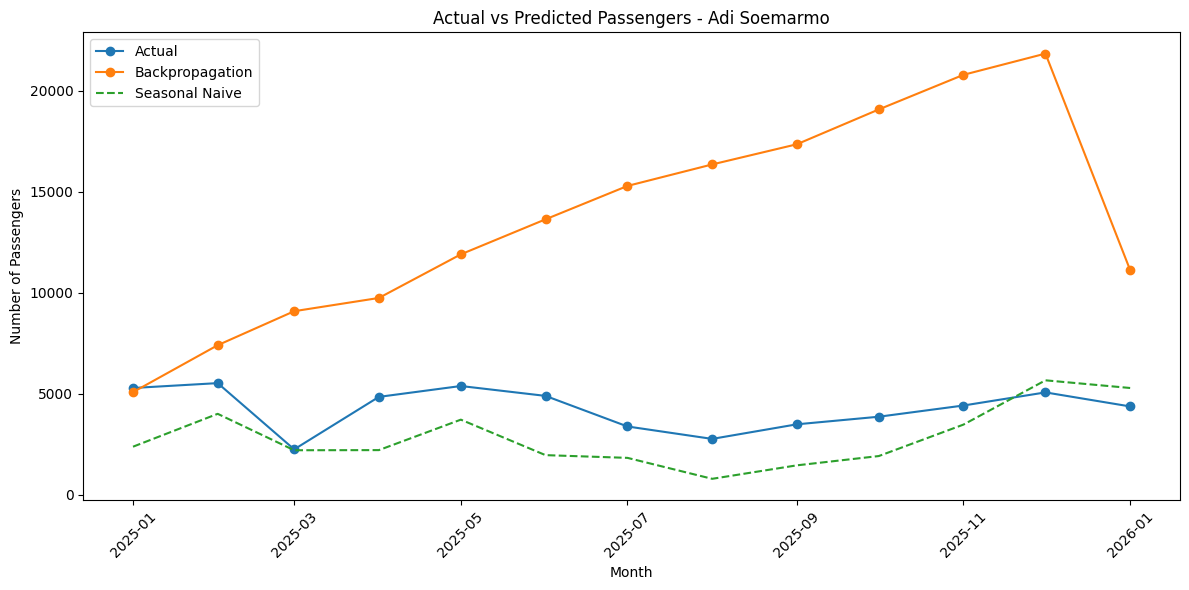

In [63]:
station_name = test_evaluation["Station"].iloc[0]
plot_data = test_evaluation[test_evaluation["Station"] == station_name].copy()

plt.figure(figsize=(12, 6))

# Actual
plt.plot(plot_data["Month"], plot_data["Passengers"], marker="o", label="Actual")

# Backpropagation
plt.plot(plot_data["Month"], plot_data["Prediction_Backprop"], marker="o", label="Backpropagation")

# Seasonal Naive
plt.plot(plot_data["Month"], plot_data["lag_12"], linestyle="--", label="Seasonal Naive")

plt.xlabel("Month")
plt.ylabel("Number of Passengers")
plt.title(f"Actual vs Predicted Passengers - {station_name}")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#**BACKPROPAGATION TRAINING LOSS**

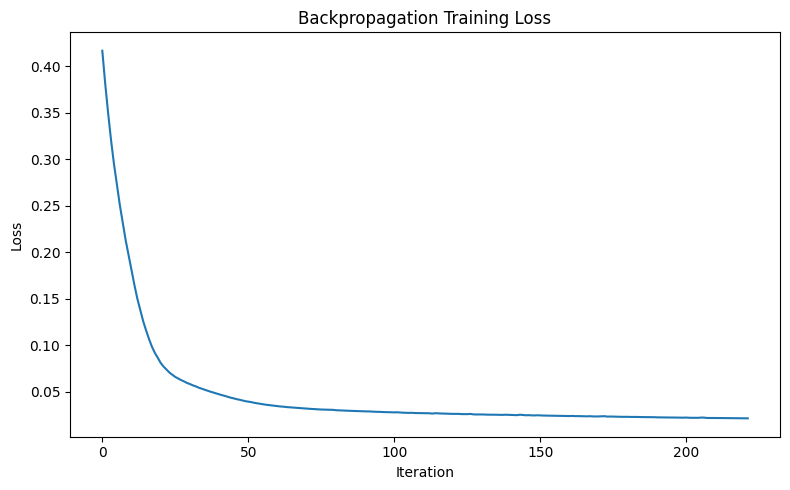

In [64]:
trained_pipeline = model.regressor_
trained_mlp = trained_pipeline.named_steps["mlp"]

plt.figure(figsize=(8, 5))
plt.plot(trained_mlp.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Backpropagation Training Loss")
plt.tight_layout()
plt.show()

In [65]:
print("TRAINING INFORMATION")
print("Number of iterations:", trained_mlp.n_iter_)
print("Final training loss:", trained_mlp.loss_)
print("\nProgram finished successfully.")

TRAINING INFORMATION
Number of iterations: 222
Final training loss: 0.021515756110363295

Program finished successfully.
